<a href="https://colab.research.google.com/github/seirah-yang/BootCamp/blob/main/%ED%86%B5%EA%B3%84Tool_3_ANOVA(pre_post_hoc_test).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 3. ANOVA(pre/post hoc test)

제품별 평균 판매액 분석

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
from pandas import Series, DataFrame
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/pharma-data.csv")
df.head()
#'['Distributor', 'Customer Name', 'City', 'Country', 'Latitude', 'Longitude', 'Channel', 'Sub-channel',
 #'Product Name', 'Product Class', 'Quantity', 'Price', 'Sales', 'Month', 'Year', 'Name of Sales Rep',
 #'Manager', 'Sales Team']

,Distributor,Customer Name,City,Country,Latitude,Longitude,Channel,Sub-channel,Product Name,Product Class,Quantity,Price,Sales,Month,Year,Name of Sales Rep,Manager,Sales Team
0,Gottlieb-Cruickshank,"Zieme, Doyle and Kunze",Lublin,Poland,51.2333,22.5667,Hospital,Private,Topipizole,Mood Stabilizers,4.0,368,1472.0,January,2018,Mary Gerrard,Britanny Bold,Delta
1,Gottlieb-Cruickshank,Feest PLC,Świecie,Poland,53.4167,18.4333,Pharmacy,Retail,Choriotrisin,Antibiotics,7.0,591,4137.0,January,2018,Jessica Smith,Britanny Bold,Delta
2,Gottlieb-Cruickshank,Medhurst-Beer Pharmaceutical Limited,Rybnik,Poland,50.0833,18.5000,Pharmacy,Institution,Acantaine,Antibiotics,30.0,66,1980.0,January,2018,Steve Pepple,Tracy Banks,Bravo
3,Gottlieb-Cruickshank,Barton Ltd Pharma Plc,Czeladź,Poland,50.3333,19.0833,Hospital,Private,Lioletine Refliruvax,Analgesics,6.0,435,2610.0,January,2018,Mary Gerrard,Britanny Bold,Delta
4,Gottlieb-Cruickshank,Keeling LLC Pharmacy,Olsztyn,Poland,53.7800,20.4942,Pharmacy,Retail,Oxymotroban Fexoformin,Analgesics,20.0,458,9160.0,January,2018,Anne Wu,Britanny Bold,Delta


In [ ]:
df.loc[df["Product Class"] == "Mood Stabilizers", "Product Name"], (df.loc[df["Product Class"] == "Analgesics", "Product Name"])

(0                   Topipizole
 5                    Pazofenac
 7         Morphizolid Tianalin
 8                      Lovapur
 10                Trazobalamin
                   ...         
 254052              Topipizole
 254060              Adriacaine
 254079                Adideine
 254080             Feruprazole
 254081             Feruprazole
 Name: Product Name, Length: 46415, dtype: object,
 3           Lioletine Refliruvax
 4         Oxymotroban Fexoformin
 6                      Symbitrim
 9                        Ampysin
 15            Neuropogen Empibax
                    ...          
 254035              Alglutriptan
 254036      Paronium Atracustone
 254042          Dantolac Pazocor
 254062              Topifribrate
 254076                Dasagestin
 Name: Product Name, Length: 44751, dtype: object)

In [ ]:
#1️. 데이터 불러오기
df = pd.read_csv("/content/drive/MyDrive/pharma-data.csv")
set(df["Product Class"].values.tolist())

{'Analgesics',
 'Antibiotics',
 'Antimalarial',
 'Antipiretics',
 'Antiseptics',
 'Mood Stabilizers'}

분석 대상 변수: Product Class
분석 대상 클래스: ['Antimalarial' 'Antiseptics' 'Antipiretics' 'Mood Stabilizers'
 'Antibiotics' 'Analgesics']
총 데이터 건수: 500

--- 1. 정규성 검정 (Shapiro/K-S Test) ---
[Antimalarial] (n=76, Kolmogorov-Smirnov) p=0.9010 → 정규성 만족
[Antiseptics] (n=73, Kolmogorov-Smirnov) p=0.6651 → 정규성 만족
[Antipiretics] (n=96, Kolmogorov-Smirnov) p=0.7403 → 정규성 만족
[Mood Stabilizers] (n=88, Kolmogorov-Smirnov) p=0.7903 → 정규성 만족
[Antibiotics] (n=76, Kolmogorov-Smirnov) p=0.3759 → 정규성 만족
[Analgesics] (n=91, Kolmogorov-Smirnov) p=0.5685 → 정규성 만족

--- 2. 등분산성 검정 (Levene’s Test) ---
Levene’s p=0.1005
[Standard One-way ANOVA]
          Source         F     p-unc
0  Product Class  0.332754  0.893154

--- 4. 사후검정 (Post-hoc Test) ---
사후검정 생략 (p>=0.05 또는 그룹 수<3)


/tmp/ipython-input-3026891785.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Product Class', y='Sales', data=df, palette='Set2')


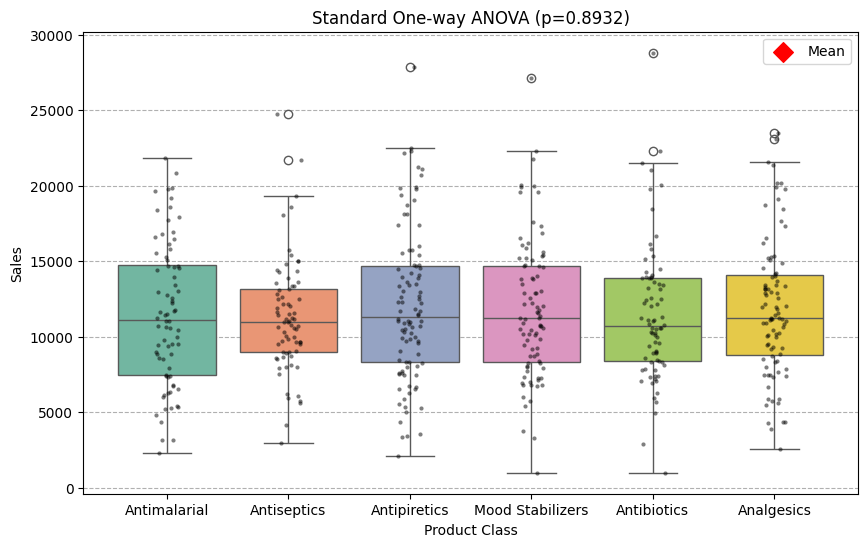

In [ ]:
!pip install pingouin
import pandas as pd
import numpy as np
from scipy.stats import shapiro, levene, f_oneway, ttest_ind, kstest
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로드
df = pd.read_csv("/content/drive/MyDrive/pharma-data.csv")

# 1  데이터 생성 (Product Class 기준)
class_list = ['Analgesics', 'Antibiotics', 'Antimalarial', 'Antipiretics', 'Antiseptics', 'Mood Stabilizers']

data_dict = {
    'Product Class': np.random.choice(class_list, 500),
    'Sales': np.concatenate([
        np.random.normal(loc=10000, scale=3000, size=150),
        np.random.normal(loc=12000, scale=4000, size=150),
        np.random.normal(loc=9000, scale=2500, size=100),
        np.random.normal(loc=15000, scale=5000, size=100)
    ]).clip(min=1000)}

df = pd.DataFrame(data_dict)

print(f"분석 대상 변수: Product Class")
print(f"분석 대상 클래스: {df['Product Class'].unique()}")
print(f"총 데이터 건수: {len(df)}")

alpha = 0.05

#  그룹 수 확인
classes = df['Product Class'].unique()
class_groups = [df.loc[df['Product Class'] == c, 'Sales'] for c in classes]

#  정규성 검정
print("\n--- 1. 정규성 검정 (Shapiro/K-S Test) ---")

for c in classes:
    sales_data = df.loc[df['Product Class'] == c, 'Sales']
    n = len(sales_data)
    if n <= 50:
        stat, p = shapiro(sales_data)
        test_name = "Shapiro-Wilk"
    else:
        stat, p = kstest((sales_data - sales_data.mean()) / sales_data.std(ddof=0), 'norm')
        test_name = "Kolmogorov-Smirnov"

    print(f"[{c}] (n={n}, {test_name}) p={p:.4f} → {'정규성 위반' if p < alpha else '정규성 만족'}")

# 4.  등분산성 검정
print("\n--- 2. 등분산성 검정 (Levene’s Test) ---")
stat_levene, p_levene = levene(*class_groups)
print(f"Levene’s p={p_levene:.4f}")
use_welch = p_levene < alpha

# 5. 그룹 수에 따라 분석 방법 선택

if len(classes) == 2:
    print("그룹 수 2개 → 독립표본 t-test 수행")
    stat, p = ttest_ind(*class_groups)
    print(f"t={stat:.4f}, p={p:.4f}")
    p_main = p
    anova_type = "Independent t-test"
else:
    if use_welch:
        aov_result = pg.welch_anova(dv='Sales', between='Product Class', data=df)
        p_main = aov_result.loc[0, 'p-unc']
        anova_type = "Welch’s One-way ANOVA"
    else:
        stat, p = f_oneway(*class_groups)
        p_main = p
        aov_result = pd.DataFrame({
            'Source': ['Product Class'],
            'F': [stat],
            'p-unc': [p]
        })
        anova_type = "Standard One-way ANOVA"

    print(f"[{anova_type}]")
    print(aov_result)

#  사후검정
print("\n--- 4. 사후검정 (Post-hoc Test) ---")
if len(classes) >= 3 and p_main < alpha:
    if use_welch:
        print(" Games-Howell Test (등분산 위반)")
        posthoc = pg.pairwise_gameshowell(dv='Sales', between='Product Class', data=df)
        sig_pairs = posthoc[posthoc['pval'] < alpha]
    else:
        print(" Tukey HSD Test (등분산 만족)")
        tukey = pairwise_tukeyhsd(endog=df['Sales'], groups=df['Product Class'], alpha=alpha)
        posthoc = pd.DataFrame(tukey._results_table.data[1:], columns=tukey._results_table.data[0])
        posthoc = posthoc.rename(columns={'reject': 'significant', 'p-adj': 'pval'})
        sig_pairs = posthoc[posthoc['significant'] == True]

    print(f"\n유의한 차이 그룹 쌍: {len(sig_pairs)}개")
    print(sig_pairs)
else:
    print("사후검정 생략 (p>=0.05 또는 그룹 수<3)")


# 시각화
plt.figure(figsize=(10,6))
sns.boxplot(x='Product Class', y='Sales', data=df, palette='Set2')
sns.stripplot(x='Product Class', y='Sales', data=df, color='black', alpha=0.5, size=3, jitter=True)

mean_sales = df.groupby('Product Class')['Sales'].mean().reset_index()
plt.scatter(mean_sales['Product Class'], mean_sales['Sales'], color='red', marker='D', s=100, label='Mean')

plt.title(f"{anova_type} (p={p_main:.4f})")
plt.xlabel("Product Class")
plt.ylabel("Sales")
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.show()
